<a href="https://colab.research.google.com/github/aniruddh-alt/MNIST-NeuralNetwork_From_Scratch/blob/main/MNIST_PyTorch_FNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.optim as optim
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
train = pd.read_csv('/content/sample_data/mnist_train_small.csv')
test = pd.read_csv('/content/sample_data/mnist_test.csv')

train

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19995,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19996,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19997,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
class MNISTDataset(Dataset):
  def __init__(self, transform=None, target_transform=None, is_test=False, path='/content/sample_data/mnist_train_small.csv'):
    self.transform = transform
    self.target_transform = target_transform
    self.data = pd.read_csv(path)
    self.is_test = is_test

    self.labels = self.data.iloc[:, 0].values
    self.images = self.data.iloc[:, 1:].values

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img = self.images[idx]
    img = img.reshape(28, 28).astype(np.uint8)

    img = torch.tensor(img, dtype=torch.float32)
    img = img.unsqueeze(0)
    if self.transform:
      img = self.transform(img)

    if self.is_test:
      return img, self.labels[idx]
    else:
      return img, self.labels[idx]

In [5]:

dataset = MNISTDataset(path='/content/sample_data/mnist_train_small.csv')
test_dataset = MNISTDataset(is_test=True, path='/content/sample_data/mnist_test.csv')

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [6]:
Config = {
    'epochs': 15,
    'alpha': 0.001,
    'batch_size': 64
}

class FNN(nn.Module):
  def __init__(self):
    super(FNN, self).__init__()
    self.fc1 = nn.Linear(784, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 128)
    self.fc4 = nn.Linear(128, 10)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    x = x.view(-1, 784)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    x = self.relu(x)
    x = self.fc4(x)
    return x

model = FNN()
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=Config['alpha'])
criterion = nn.CrossEntropyLoss()




In [7]:
### Training
patience = 2
best_val_loss = np.inf
epochs_no_improve = 0
for epoch in range(Config['epochs']):
  model.train()
  running_loss = 0.0
  correct = 0.0
  total = 0
  print(f'#####Epoch: {epoch}######')
  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
    _, predicted = torch.max(output.data, 1)
    total += target.size(0)
    correct += (predicted == target).sum().item()


  epoch_loss = running_loss / len(train_loader)
  accuracy = (correct / total) * 100
  print(f'Epoch: {epoch}, Loss: {epoch_loss}, Accuracy: {accuracy}')
    # Early stopping
  if epoch_loss < best_val_loss:
      best_val_loss = epoch_loss
      epochs_without_improvement = 0  # Reset the patience counter
  else:
      epochs_without_improvement += 1
      if epochs_without_improvement >= patience:
          print("Early stopping triggered!")
          break




#####Epoch: 0######
Epoch: 0, Loss: 0.3892723617795557, Accuracy: 89.07945397269863
#####Epoch: 1######
Epoch: 1, Loss: 0.144683035786826, Accuracy: 95.55477773888694
#####Epoch: 2######
Epoch: 2, Loss: 0.11291570782203215, Accuracy: 96.41482074103706
#####Epoch: 3######
Epoch: 3, Loss: 0.09134276361002351, Accuracy: 97.08485424271214
#####Epoch: 4######
Epoch: 4, Loss: 0.0811177688976601, Accuracy: 97.41987099354968
#####Epoch: 5######
Epoch: 5, Loss: 0.06646300561074465, Accuracy: 97.92989649482475
#####Epoch: 6######
Epoch: 6, Loss: 0.06160471898082572, Accuracy: 98.03990199509975
#####Epoch: 7######
Epoch: 7, Loss: 0.052806474189586436, Accuracy: 98.4399219960998
#####Epoch: 8######
Epoch: 8, Loss: 0.05091880647770201, Accuracy: 98.4199209960498
#####Epoch: 9######
Epoch: 9, Loss: 0.05573846924173744, Accuracy: 98.44992249612481
#####Epoch: 10######
Epoch: 10, Loss: 0.052442356151585934, Accuracy: 98.4649232461623
Early stopping triggered!


In [8]:
#### Testing

model.eval()
running_loss = 0.0
correct = 0.0
total = 0
print(f'#####Epoch: {epoch}######')
for batch_idx, (data, target) in enumerate(test_loader):
  data, target = data.to(device), target.to(device)
  output = model(data)
  loss = criterion(output, target)
  running_loss+=loss.item()
  _, predicted = torch.max(output.data, 1)
  total += target.size(0)
  correct += (predicted == target).sum().item()


epoch_loss = running_loss / len(train_loader)
accuracy = (correct / total) * 100
print(f'Loss: {epoch_loss}, Accuracy: {accuracy}')



#####Epoch: 10######
Loss: 0.09587682716570713, Accuracy: 96.32963296329633


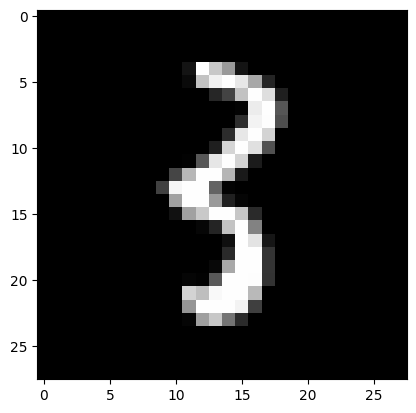

Predicted: 3, Actual: 3


In [20]:
# test this out with a test dataset
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch import Tensor
random_test = np.random.randint(0, len(test_dataset))
image, label = test_dataset[random_test]
image = image.to(device)
# plot the image
plt.imshow(Tensor.cpu(image).squeeze(0), cmap='gray')
plt.show()
pred = model(image.unsqueeze(0))
pred = torch.argmax(pred)
print(f'Predicted: {pred}, Actual: {label}')
